In [ ]:
import tensorflow as tf 


In [4]:
import sys
!{sys.executable} -m pip install kagglehub

Looking in indexes: https://pypi.org/simple/
     -------------------------------------- 69.1/69.1 kB 377.5 kB/s eta 0:00:00
     ------------------------------------ 158.6/158.6 kB 944.7 kB/s eta 0:00:00
     ------------------------------------ 160.4/160.4 kB 962.3 kB/s eta 0:00:00
  Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)



[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install kagglehub

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple/

   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ---------------------------------------- 0/3 [protobuf]
   ------------- -------------------------- 1/3 [kagglesdk]
   ------------- -------------------------- 1/3 [

In [7]:
import sys
!{sys.executable} -m pip install seaborn

Looking in indexes: https://pypi.org/simple/
     -------------------------------------- 294.9/294.9 kB 2.6 MB/s eta 0:00:00



[notice] A new release of pip available: 22.2.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mdwasimakhtar03/social-network-adscsv")

print("Path to dataset files:", path)

c:\Users\manas\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.46k/1.46k [00:00<00:00, 1.16MB/s]

Extracting files...
Path to dataset files: C:\Users\manas\.cache\kagglehub\datasets\mdwasimakhtar03\social-network-adscsv\versions\1


In [8]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [9]:
df = pd.read_csv("Social_Network_Ads.csv")
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [10]:
X = df.drop(columns = ['Purchased'] , axis = 1)
y = df['Purchased']


In [11]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [12]:
import tensorflow as tf
from tensorflow import keras 
from keras import Sequential
from keras.layers import Dense


In [16]:
model = Sequential()

model.add(Dense(32,activation = 'relu' , input_dim = 2 ))
model.add(Dense(32 ,activation= 'relu' ))
model.add(Dense(1 , activation = 'sigmoid' ))

model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:

from keras.callbacks import ModelCheckpoint 

checkpoint = ModelCheckpoint('bestModel.keras' , monitor = 'val_loss' , save_best_only= True)


In [26]:
model.compile(optimizer = 'adam' , loss = 'binary_crossentropy' , metrics = ['accuracy'])

In [27]:
from gc import callbacks


history = model.fit(X , y , validation_split=0.2 , epochs = 100, callbacks = [checkpoint])


Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7125 - loss: 2380.8408 - val_accuracy: 0.3625 - val_loss: 1726.9763
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5125 - loss: 489.8568 - val_accuracy: 0.6375 - val_loss: 255.8477
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5375 - loss: 238.9649 - val_accuracy: 0.3625 - val_loss: 362.0079
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4250 - loss: 159.4518 - val_accuracy: 0.3625 - val_loss: 86.4953
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5437 - loss: 64.2216 - val_accuracy: 0.3625 - val_loss: 65.9457
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5469 - loss: 71.9730 - val_accuracy: 0.3625 - val_loss: 22.0037
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5656 - loss: 32.3571 - val_accuracy: 0.3625 - val_loss: 35.7675
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6438 - loss: 28.8962 -

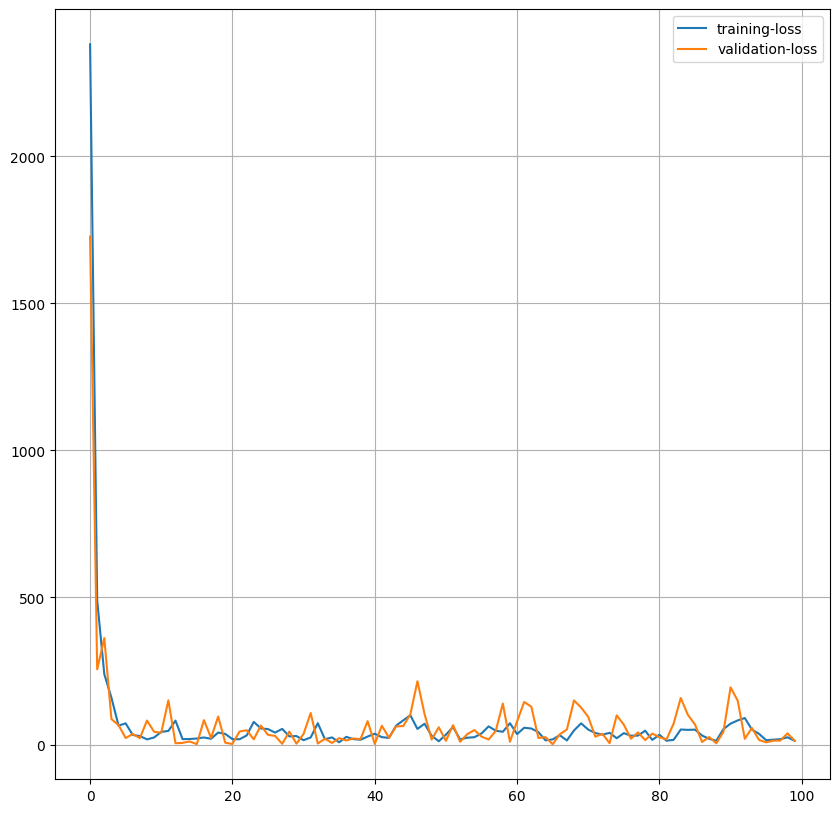

In [28]:
plt.figure(figsize = (10 , 10))
plt.plot(history.history['loss'] , label ="training-loss")
plt.plot(history.history['val_loss'] , label ="validation-loss")
plt.legend()
plt.grid()
plt.show()


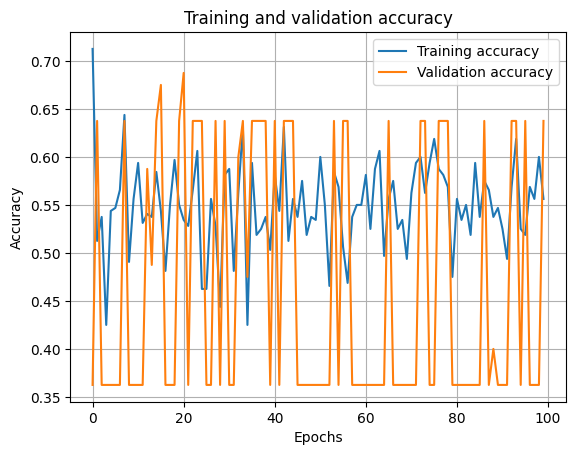

In [32]:

plt.plot(history.history['accuracy'] ,label = "Training accuracy" )
plt.plot(history.history['val_accuracy'] ,label = "Validation accuracy" )
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()
